# Notebook 01 — Initial Data Exploration

**Phase 1 learning checkpoint.** Before we touch any model, we have to *meet* the data.

## What you will do here

1. Load the two raw datasets that `src/data_loader.py` just downloaded.
2. Look at their **shape**, **schema**, and **a few sample rows**.
3. Run a missingness audit — which columns are sparse?
4. Get a feel for the **target** (`SalePrice`) — is it skewed?
5. Sanity-check the Zillow time series — does it really cover the years it claims?

## Reading order

Pair this notebook with [`docs/01_data_science_fundamentals.md`](../docs/01_data_science_fundamentals.md) (the *why*) and [`docs/02_understanding_the_data.md`](../docs/02_understanding_the_data.md) (the *what*).

> ⚠️ **Beginner pitfall warning.** Don't be tempted to skip this notebook and jump straight to modeling. "Understanding the data" *is* the job for the first 30–50% of any real project. Skipping it produces models that look great on paper and fail in production.

## 0. Setup

We import our own `data_loader` module so notebook and production code use the **same** load logic — no copy-paste drift.

In [1]:
# This 'magic' makes edits to src/*.py auto-reload without restarting the kernel.
# Saves you a lot of frustration during development.
%load_ext autoreload
%autoreload 2

# Make project root importable so `from src.data_loader import ...` works
# from inside notebooks/.
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns; pandas truncates wide DataFrames by default and Ames is wide.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

from src.data_loader import load_ames, load_zillow_zhvi
print("Setup complete.")

Setup complete.


## 1. Ames Housing — first look

We expect ~2,930 rows and ~82 columns. Each row is one home sale in Ames, IA between 2006 and 2010. The target variable we'll predict later is `SalePrice`.

In [2]:
ames = load_ames()
print(f"Shape: {ames.shape}")
ames.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### 1a. Column inventory

How many numeric vs. categorical columns? This drives every preprocessing decision in Phase 2.

In [3]:
dtypes_summary = ames.dtypes.value_counts()
print("Dtype breakdown:")
print(dtypes_summary)
print(f"\nTotal numeric:    {ames.select_dtypes(include=np.number).shape[1]}")
print(f"Total categorical: {ames.select_dtypes(include='object').shape[1]}")

Dtype breakdown:
object     43
int64      28
float64    11
Name: count, dtype: int64

Total numeric:    39
Total categorical: 43


### 1b. Missingness audit

A column with 80% missing values is usually unusable. A column with 5% missing is often fine after imputation. **Knowing which is which is the first decision of Phase 2.**

> 📘 **Concept — "NA" can be meaningful.** In the Ames data, many `NA`s do **not** mean "unknown". They mean "this feature does not exist for this home" (e.g. `PoolQC = NA` means "no pool"). The data dictionary in `data/raw/ames_data_dictionary.txt` tells you which `NA`s are structural vs. truly missing — read it. We'll handle this carefully in Phase 2.

In [4]:
missing = ames.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(ames) * 100).round(2)
missingness = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missingness = missingness[missingness["n_missing"] > 0]
print(f"{len(missingness)} columns have at least one missing value:")
missingness.head(20)

27 columns have at least one missing value:


,n_missing,pct_missing
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Yr Blt,159,5.43
Garage Cond,159,5.43


### 1c. The target — `SalePrice`

Distribution shape matters. If `SalePrice` is right-skewed (long tail of expensive homes), some models do better on `log(SalePrice)` than on raw price. We'll explore that in Phase 3, but a quick histogram now plants the seed.

count      2930.0
mean     180796.0
std       79887.0
min       12789.0
25%      129500.0
50%      160000.0
75%      213500.0
max      755000.0
Name: SalePrice, dtype: float64

Skewness: 1.74   (>1 means notably right-skewed)


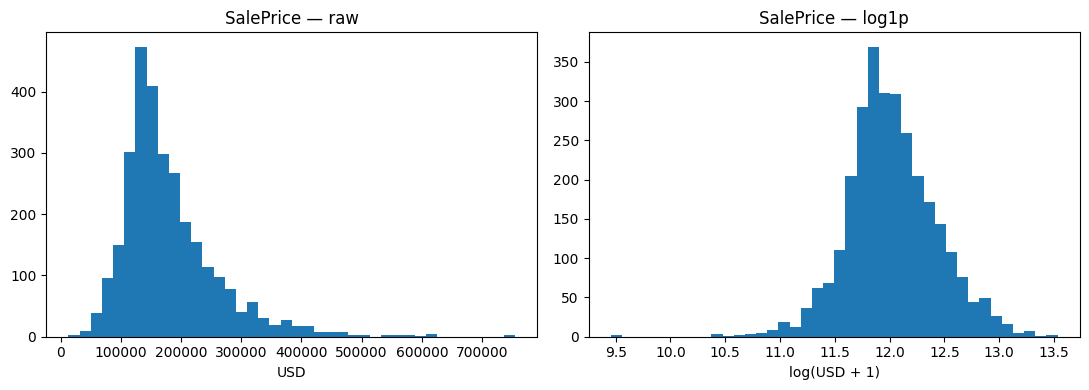

In [5]:
print(ames["SalePrice"].describe().round(0))
print(f"\nSkewness: {ames['SalePrice'].skew():.2f}   (>1 means notably right-skewed)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ames["SalePrice"], bins=40)
axes[0].set_title("SalePrice — raw")
axes[0].set_xlabel("USD")
axes[1].hist(np.log1p(ames["SalePrice"]), bins=40)
axes[1].set_title("SalePrice — log1p")
axes[1].set_xlabel("log(USD + 1)")
plt.tight_layout()
plt.show()

## 2. Zillow ZHVI — first look

This is structurally very different from Ames: one row per US ZIP code, and one column for **every** month from 2000 to today. Look at the column types carefully — most should be dates-as-strings.

In [6]:
zhvi = load_zillow_zhvi()
print(f"Shape: {zhvi.shape}")
zhvi.iloc[:5, :8]

Shape: (26283, 324)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX"
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA"
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX"
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA"
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX"


### 2a. Identify ID columns vs. value columns

The first handful of columns describe the ZIP (region name, state, metro). The rest are monthly value columns. We separate them so we can talk about each.

In [7]:
# Heuristic: a column whose name looks like a date (YYYY-MM-DD) is a value
# column. Everything else is metadata.
import re
date_col_pattern = re.compile(r"^\d{4}-\d{2}-\d{2}$")
date_cols = [c for c in zhvi.columns if date_col_pattern.match(c)]
id_cols = [c for c in zhvi.columns if c not in date_cols]

print(f"ID/metadata columns ({len(id_cols)}): {id_cols}")
print(f"Date columns: {len(date_cols)}  (from {date_cols[0]} to {date_cols[-1]})")

ID/metadata columns (9): ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
Date columns: 315  (from 2000-01-31 to 2026-03-31)


### 2b. Geographic coverage

How many ZIPs and which states? This tells us whether we can do a national heatmap or should restrict to one metro for now.

In [8]:
print(f"Unique ZIPs: {zhvi['RegionName'].nunique():,}")
print(f"States covered: {zhvi['State'].nunique()}")
print("\nTop 5 states by number of ZIPs:")
print(zhvi['State'].value_counts().head())

Unique ZIPs: 26,283
States covered: 51

Top 5 states by number of ZIPs:
State
NY    1561
CA    1543
TX    1513
PA    1362
IL    1084
Name: count, dtype: int64


### 2c. Sanity-check a known ZIP

Pick an Ames, Iowa ZIP (50010) and plot its price trajectory. This is also our first time-series chart, and it primes the Phase 5 forecasting work.

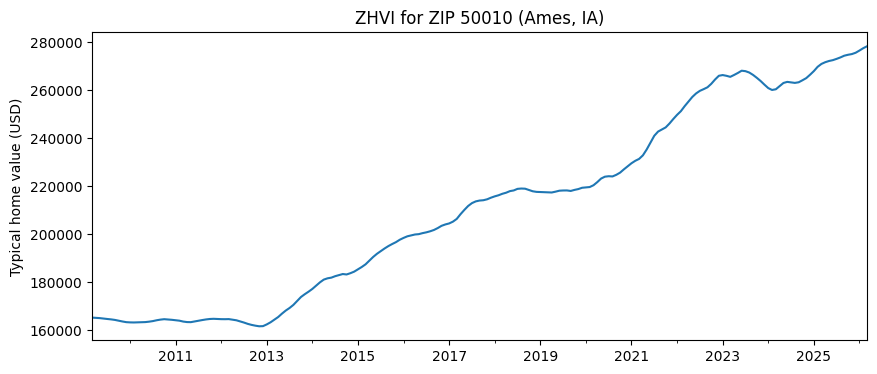

Series spans 2009-03-31 to 2026-03-31, with 205 non-null monthly observations.


In [9]:
ames_zip_row = zhvi[zhvi["RegionName"] == 50010]
if not ames_zip_row.empty:
    series = ames_zip_row[date_cols].iloc[0]
    series.index = pd.to_datetime(series.index)
    series = series.dropna()
    series.plot(figsize=(10, 4), title="ZHVI for ZIP 50010 (Ames, IA)")
    plt.ylabel("Typical home value (USD)")
    plt.xlabel("")
    plt.show()
    print(f"Series spans {series.index.min().date()} to {series.index.max().date()},"
          f" with {len(series)} non-null monthly observations.")
else:
    print("ZIP 50010 not in dataset — Zillow's coverage may have changed. Pick another.")

## 3. Wrap-up — what did we learn?

Write your own answers below before moving on:

1. **Ames dataset shape and target:** how many rows? How many features? What is the range of `SalePrice`?
2. **Most-missing columns:** name the top 3 — are they candidates for *imputation* or *dropping*? (Hint: check the data dictionary for whether `NA` is structural.)
3. **Target skew:** is the raw target skewed enough that you'd consider a log-transform?
4. **Zillow coverage:** does the dataset go far enough back / forward to give us useful trend signal?
5. **Joining the two datasets:** Ames is by individual home; Zillow is by ZIP. What's the granularity mismatch and what does that mean for how we'll combine them later?

Once you can answer those without re-reading the cells above, you're ready for **Phase 2: Data Cleaning & EDA**.